# 30-Day Readmission Prediction — Version 3

- Embed the **full dataset first**, then sample — guarantees row alignment via pandas index
- **Dual-input functional model**: separate branches for text embeddings and structured features
- **Attention layer** on the text branch — learns which parts of the embedding to focus on

# 1. Loading the Dataset

In [ ]:
from google.colab import auth
auth.authenticate_user()

!pip install -q gcsfs

import pandas as pd
df = pd.read_parquet('gs://ba865-t9-mimiciv/parquet/cohort_model_input')

print('Shape:', df.shape)
df.head(3)

Shape: (272842, 13)


,hadm_id,readmitted_30d,anchor_age,gender,los_days,prior_admissions,icd10_chapter,admission_type,insurance,creatinine,hemoglobin,heart_rate_discharge,discharge_text
0,20000502,1,49,M,4.71,0,8,EW EMER.,Private,0.8,12.8,82.0,\nName: ___ Unit No: ___\...
1,20002493,0,70,F,11.90,0,C,OBSERVATION ADMIT,Medicare,0.8,7.9,82.0,\nName: ___ Unit No: ___...
2,20003332,0,57,M,5.92,0,E,OBSERVATION ADMIT,Private,0.6,14.0,82.0,\nName: ___ Unit No: ___\n...


# 2. EDA

In [ ]:
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

Shape: (272842, 13)

Column types:
hadm_id                   int32
readmitted_30d            int32
anchor_age                int32
gender                   object
los_days                float64
prior_admissions          int32
icd10_chapter            object
admission_type           object
insurance                object
creatinine              float64
hemoglobin              float64
heart_rate_discharge    float64
discharge_text           object
dtype: object


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
insurance,3048,1.11713
readmitted_30d,0,0.00000
anchor_age,0,0.00000
gender,0,0.00000
hadm_id,0,0.00000
los_days,0,0.00000
prior_admissions,0,0.00000
icd10_chapter,0,0.00000
admission_type,0,0.00000
creatinine,0,0.00000


In [ ]:
counts = df['readmitted_30d'].value_counts()
pcts   = df['readmitted_30d'].value_counts(normalize=True)
print(counts)
print(pcts)
neg, pos = counts[0], counts[1]
print(f'\nImbalance ratio (neg/pos): {neg/pos:.2f}x')

readmitted_30d
0    211694
1     61148
Name: count, dtype: int64
readmitted_30d
0    0.775885
1    0.224115
Name: proportion, dtype: float64

Imbalance ratio (neg/pos): 3.46x


In [ ]:
num_cols = ['anchor_age', 'los_days', 'prior_admissions',
            'creatinine', 'hemoglobin', 'heart_rate_discharge']
df.groupby('readmitted_30d')[num_cols].mean()

,anchor_age,los_days,prior_admissions,creatinine,hemoglobin,heart_rate_discharge
readmitted_30d,,,,,,
0,59.919067,5.649381,1.936328,1.138807,10.971250,82.106505
1,59.550991,7.013293,4.037139,1.312977,10.369446,82.357022


In [ ]:
cat_cols = ['gender', 'icd10_chapter', 'admission_type', 'insurance']
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().head(10))


--- gender ---
gender
F    137377
M    135465
Name: count, dtype: int64

--- icd10_chapter ---
icd10_chapter
4    40658
5    33127
I    21515
2    19340
7    18161
K    14086
9    13117
8    10623
1     8698
0     8438
Name: count, dtype: int64

--- admission_type ---
admission_type
EW EMER.                       135570
OBSERVATION ADMIT               49970
SURGICAL SAME DAY ADMISSION     30435
URGENT                          27587
DIRECT EMER.                    18045
ELECTIVE                         9834
EU OBSERVATION                    901
DIRECT OBSERVATION                455
AMBULATORY OBSERVATION             45
Name: count, dtype: int64

--- insurance ---
insurance
Medicare     136814
Private       82604
Medicaid      43137
Other          7193
No charge        46
Name: count, dtype: int64


In [ ]:
df['text_length'] = df['discharge_text'].astype(str).apply(len)
df['text_length'].describe()

,text_length
count,272842.000000
mean,10883.954992
std,4526.047013
min,353.000000
25%,7741.000000
50%,10193.000000
75%,13224.000000
max,60381.000000


In [ ]:
for i in range(3):
    print(f'\n--- Sample {i} ---\n')
    print(df['discharge_text'].iloc[i][:800])


--- Sample 0 ---

 
Name:  ___                  Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   M
 
Service: SURGERY
 
Allergies: 
Patient recorded as having No Known Allergies to Drugs
 
Attending: ___.
 
Chief Complaint:
s/p 14 foot Fall
 
Major Surgical or Invasive Procedure:
___ ORIF right distal tibia
 
History of Present Illness:
___ yo male s/p fall from approx 15 ft off of ladder, no reported 
LOC. transported to ___ for further care.
 
Past Medical History:
Denies
 
Family History:
Noncontributory
 
Physical Exam:
On presentation:
Gen: NAD, in a C-Collar
HEENT:  EOMI, PERRL, trachea is midline, no LAD
RESP: CTA-B
CV: RRR, nl S1 and S2, no MRG
ABD: soft, NT/ND, +BS, normal rectal tone with no gross blood.
EXT: Pelvis is stable, ___ st

--- Sample 1 ---

 
Name:  ___                   Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: SUR

# 3. Preprocessing (full dataset)

All cleaning and encoding happens on the **full** dataframe before any sampling. This keeps the row index stable and meaningful throughout.

In [ ]:
# drop ID column — not a feature
df = df.drop(columns=['hadm_id'])

# fill missing categoricals
df['insurance'] = df['insurance'].fillna('Unknown')

# light text cleaning
df['discharge_text'] = df['discharge_text'].str.replace('___', '', regex=False)
df['discharge_text'] = df['discharge_text'].str.replace('\n', ' ', regex=False)
df['discharge_text'] = df['discharge_text'].str.replace(r'\s+', ' ', regex=True)

# drop helper column created during EDA
df = df.drop(columns=['text_length'], errors='ignore')

# one-hot encode categoricals
df = pd.get_dummies(df, columns=['gender', 'icd10_chapter', 'admission_type', 'insurance'], drop_first=True)

# --- CRITICAL: reset to a clean 0..N-1 integer index ---
# This ensures embeddings_full[df_sample.index] is always correct after sampling.
df = df.reset_index(drop=True)

print('Full dataset shape after preprocessing:', df.shape)
print('Index range:', df.index[0], '..', df.index[-1])

Full dataset shape after preprocessing: (272842, 54)
Index range: 0 .. 272841


# 4. ClinicalBERT Embeddings — Full Dataset

**Why embed everything before sampling?**

If we embed only the 50k sample, we have to re-run the 20-minute encoding step every time we change the sample or the random seed. By embedding the full dataset once and saving it to GCS, we can freely experiment with different sample sizes, seeds, or train/test ratios without ever touching ClinicalBERT again.

**Row alignment:** After `reset_index()`, row `i` in the dataframe corresponds exactly to `embeddings_full[i]`. When we sample, `df_sample.index` gives us the original row numbers, so `embeddings_full[df_sample.index]` is always perfectly aligned — no shuffling, no manual tracking.

In [ ]:
!pip install -q transformers accelerate

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

CBERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer_cbert = AutoTokenizer.from_pretrained(CBERT_MODEL)
model_cbert     = AutoModel.from_pretrained(CBERT_MODEL)
model_cbert.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cbert = model_cbert.to(device)
print('Using device:', device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda


In [ ]:
def mean_pool(token_embeddings, attention_mask):
    """Mean-pool token embeddings, ignoring padding."""
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


def get_clinicalbert_embeddings(texts, batch_size=32, max_length=512):
    """Encode texts with ClinicalBERT mean pooling. Returns (N, 768) numpy array."""
    all_emb = []
    for start in range(0, len(texts), batch_size):
        batch   = texts[start : start + batch_size]
        encoded = tokenizer_cbert(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            out = model_cbert(**encoded)
        emb = mean_pool(out.last_hidden_state, encoded['attention_mask'])
        all_emb.append(emb.cpu().numpy())
        if (start // batch_size) % 50 == 0:
            print(f'  {min(start + batch_size, len(texts))} / {len(texts)}')
    return np.vstack(all_emb)

# second version of embeddings to try to capture a richer representation of them

def get_clinicalbert_embeddings_rich(texts, batch_size=32, max_length=512):
    """
    Returns CLS + mean pool + max pool concatenated → (N, 2304).
    Richer than mean pooling alone:
      - CLS captures global document-level context
      - mean pool captures overall semantic content
      - max pool captures peak/salient signals (strong local phrases)
    """
    all_emb = []
    for start in range(0, len(texts), batch_size):
        batch   = texts[start : start + batch_size]
        encoded = tokenizer_cbert(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            out = model_cbert(**encoded, output_hidden_states=False)

        token_emb  = out.last_hidden_state          # (batch, seq_len, 768)
        mask       = encoded['attention_mask']       # (batch, seq_len)

        # CLS token (position 0)
        cls_emb    = token_emb[:, 0, :]             # (batch, 768)

        # mean pool over non-padding tokens
        mask_exp   = mask.unsqueeze(-1).float()
        mean_emb   = (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)

        # max pool over non-padding tokens (mask padding with large negative)
        token_masked = token_emb.masked_fill(mask.unsqueeze(-1) == 0, -1e9)
        max_emb      = token_masked.max(dim=1).values   # (batch, 768)

        # concatenate all three → (batch, 2304)
        rich_emb = torch.cat([cls_emb, mean_emb, max_emb], dim=1)
        all_emb.append(rich_emb.cpu().numpy())

        if (start // batch_size) % 50 == 0:
            print(f'  {min(start + batch_size, len(texts))} / {len(texts)}')

    return np.vstack(all_emb)

In [ ]:
import gcsfs
import io

fs = gcsfs.GCSFileSystem()
BUCKET   = 'ba865-t9-mimiciv/embeddings/clinicalbert/'
EMB_PATH = BUCKET + 'full_embeddings.npy'

if fs.exists(EMB_PATH):
    # ---- fast path: load saved embeddings (~seconds) ----
    print('Loading saved embeddings from GCS...')
    with fs.open(EMB_PATH, 'rb') as f:
        embeddings_full = np.load(f)
    print('Loaded:', embeddings_full.shape)

else:
    # ---- slow path: embed full dataset (~20 min on T4) ----
    print(f'No saved embeddings found. Embedding {len(df):,} notes...')
    all_texts       = df['discharge_text'].tolist()
    embeddings_full = get_clinicalbert_embeddings(all_texts, batch_size=32)
    print('Done. Shape:', embeddings_full.shape)

    # save to GCS
    print('Saving to GCS...')
    with fs.open(EMB_PATH, 'wb') as f:
        np.save(f, embeddings_full)
    print('Saved to', EMB_PATH)

# sanity check: one embedding per row
assert len(embeddings_full) == len(df), \
    f'Shape mismatch: {len(embeddings_full)} embeddings vs {len(df)} rows'
print('Row alignment check passed.')

Loading saved embeddings from GCS...
Loaded: (272842, 768)
Row alignment check passed.


In [ ]:
# save to a new GCS path — keeps original mean-pooled embeddings intact
RICH_EMB_PATH = BUCKET + 'full_embeddings_rich.npy'

if fs.exists(RICH_EMB_PATH):
    print('Loading rich embeddings from GCS...')
    with fs.open(RICH_EMB_PATH, 'rb') as f:
        embeddings_rich = np.load(f)
    print('Loaded:', embeddings_rich.shape)   # expected: (N, 2304)
else:
    print(f'Embedding {len(df):,} notes with rich pooling...')
    embeddings_rich = get_clinicalbert_embeddings_rich(df['discharge_text'].tolist())
    print('Done:', embeddings_rich.shape)
    with fs.open(RICH_EMB_PATH, 'wb') as f:
        np.save(f, embeddings_rich)
    print('Saved to', RICH_EMB_PATH)

Loading rich embeddings from GCS...
Loaded: (272842, 2304)


# 5. Sampling and Train/Test Split

We sample **after** embedding. Because `df` has a clean `reset_index()` integer index, `df_sample.index` gives the original row positions in `embeddings_full`, so `embeddings_full[df_sample.index]` returns exactly the embeddings for the sampled rows — in the same order.

In [ ]:
# sample from the full dataset
N_SAMPLE   = 50_000
RANDOM_SEED = 42
df_sample  = df.sample(n=N_SAMPLE, random_state=RANDOM_SEED)

# pull aligned embeddings using the sample's original row indices
emb_sample = embeddings_full[df_sample.index]    # shape: (50000, 768)

# separate target and features
y = df_sample['readmitted_30d'].values
X_struct = df_sample.drop(columns=['readmitted_30d', 'discharge_text']).values

print('Structured features:', X_struct.shape)
print('Text embeddings:    ', emb_sample.shape)
print('Target:             ', y.shape)

Structured features: (50000, 52)
Text embeddings:     (50000, 768)
Target:              (50000,)


In [ ]:
from sklearn.model_selection import train_test_split

(
    X_struct_train, X_struct_test,
    X_emb_train,    X_emb_test,
    y_train,        y_test
) = train_test_split(
    X_struct, emb_sample, y,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print('X_struct_train:', X_struct_train.shape)
print('X_emb_train:   ', X_emb_train.shape)
print('y_train:       ', y_train.shape)

X_struct_train: (40000, 52)
X_emb_train:    (40000, 768)
y_train:        (40000,)


# 6. Preparation for Modelling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_struct_train = scaler.fit_transform(X_struct_train)
X_struct_test  = scaler.transform(X_struct_test)

print('Structured train scaled:', X_struct_train.shape)
print('Embedding train:        ', X_emb_train.shape)

Structured train scaled: (40000, 52)
Embedding train:         (40000, 768)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Class weights:', class_weight_dict)
# minority class gets a higher weight, majority gets a lower weight
# this directly rescales the loss so 1 positive example counts as ~imbalance_ratio negatives

Class weights: {np.int64(0): np.float64(0.644433703882713), np.int64(1): np.float64(2.230897936419409)}


# 7. Model Architecture

## Why a dual-input functional model?

Concatenating embeddings + structured features into a flat vector (as in Version 1 & 2) works, but it forces the first Dense layer to simultaneously learn how to use 768 embedding dimensions and however many structured features. Giving each input its own branch allows the network to develop separate representations before merging.

## Attention on the text branch

ClinicalBERT's 768-dim mean-pooled embedding is a single vector — there's no sequence to attend over at this point. To add trainable attention, we reshape the flat vector into a short sequence of chunks (e.g. 12 chunks × 64 dims) and apply `MultiHeadAttention`. This lets the model learn *which regions of the embedding space* carry the most signal for readmission prediction, rather than treating all 768 dimensions equally.

```
Text input (768,)
  └─ Reshape → (12, 64)          # treat as 12 'tokens' of 64 dims
  └─ MultiHeadAttention(4 heads) # cross-dimension attention
  └─ GlobalAveragePooling1D      # back to a flat vector
  └─ Dense(256) → Dropout

Struct input (n_struct,)
  └─ Dense(128) → BatchNorm → Dropout
  └─ Dense(64)

Concatenate → Dense(128) → Dropout → Dense(1, sigmoid)
```

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

N_STRUCT = X_struct_train.shape[1]
EMB_DIM  = 768

# ── Text embedding branch ──────────────────────────────────────────────────
text_input = layers.Input(shape=(EMB_DIM,), name='text_embedding')

# reshape flat (768,) into a sequence of 12 chunks × 64 dims
# MultiHeadAttention then learns cross-chunk interactions
x_text = layers.Reshape((12, 64))(text_input)
x_text = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text, x_text) # self-attention: Q = K = V
x_text = layers.LayerNormalization()(x_text)
x_text = layers.GlobalAveragePooling1D()(x_text)   # (batch, 768) → (batch, 64) pooled
x_text = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x_text)
x_text = layers.Dropout(0.3)(x_text)

# ── Structured features branch ─────────────────────────────────────────────
struct_input = layers.Input(shape=(N_STRUCT,), name='structured_features')
x_struct = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(struct_input)
x_struct = layers.BatchNormalization()(x_struct)
x_struct = layers.Dropout(0.3)(x_struct)
x_struct = layers.Dense(64, activation='relu')(x_struct)

# ── Merge and classify ─────────────────────────────────────────────────────
merged = layers.Concatenate()([x_text, x_struct])
x      = layers.Dense(128, activation='relu')(merged)
x      = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='sigmoid', name='readmission')(x)

model3 = models.Model(
    inputs=[text_input, struct_input],
    outputs=output,
    name='readmission_v3'
)
model3.summary()

Model: "readmission_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding      │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 12, 64)    │          0 │ text_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_features │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 64)    │        128 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      6,784 │ structured_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     16,640 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     41,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ readmission (Dense) │ (None, 1)         │        129 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 139,905 (546.50 KB)

 Trainable params: 139,649 (545.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

model3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        AUC(name='auc'),
        AUC(name='auc_pr', curve='PR'),   # primary metric for imbalanced tasks
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_auc_pr', patience=5, mode='max',
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5, patience=3,
        mode='max', min_lr=1e-6, verbose=1
    )
]

In [ ]:
# dual-input model expects a LIST of arrays matching the Input layer order
history3 = model3.fit(
    [X_emb_train, X_struct_train],   # [text_embedding, structured_features]
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5943 - auc: 0.6193 - auc_pr: 0.3327 - loss: 0.6886 - precision: 0.2920 - recall: 0.5631 - val_accuracy: 0.6745 - val_auc: 0.6654 - val_auc_pr: 0.3860 - val_loss: 0.6410 - val_precision: 0.3440 - val_recall: 0.5267 - learning_rate: 0.0010
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6357 - auc: 0.6544 - auc_pr: 0.3695 - loss: 0.6685 - precision: 0.3252 - recall: 0.5749 - val_accuracy: 0.6294 - val_auc: 0.6716 - val_auc_pr: 0.3924 - val_loss: 0.6928 - val_precision: 0.3207 - val_recall: 0.6107 - learning_rate: 0.0010
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6515 - auc: 0.6667 - auc_pr: 0.3830 - loss: 0.6602 - precision: 0.3390 - recall: 0.5775 - val_accuracy: 0.6469 - val_auc: 0.6741 - val_auc_pr: 0.4028 - val_loss: 0.6525 - val_precision: 0.3285 - val_recall: 0.5778 - learning_rate: 0.0010
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6472 - auc: 0.6703 -

# 8. Evaluation

In [ ]:
results      = model3.evaluate([X_emb_test, X_struct_test], y_test, verbose=0)
metric_names = model3.metrics_names

print('\n--- Test Set Results ---')
for name, val in zip(metric_names, results):
    print(f'  {name:15s}: {val:.4f}')


--- Test Set Results ---
  loss           : 0.6415
  compile_metrics: 0.6634


In [ ]:
from sklearn.metrics import f1_score, classification_report

# predict probabilities on test set
y_pred_prob = model3.predict([X_emb_test, X_struct_test]).ravel()

# sweep thresholds to find the one that maximises F1
# the default 0.5 is rarely optimal when classes are imbalanced
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_threshold:.2f}  (F1 = {max(f1_scores):.4f})')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Best threshold: 0.50  (F1 = 0.4312)


In [ ]:
y_pred = (y_pred_prob > best_threshold).astype(int)
print(f'Classification Report (threshold = {best_threshold:.2f})\n')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

Classification Report (threshold = 0.50)

                precision    recall  f1-score   support

Not Readmitted       0.85      0.69      0.76      7759
    Readmitted       0.35      0.57      0.43      2241

      accuracy                           0.66     10000
     macro avg       0.60      0.63      0.60     10000
  weighted avg       0.74      0.66      0.69     10000



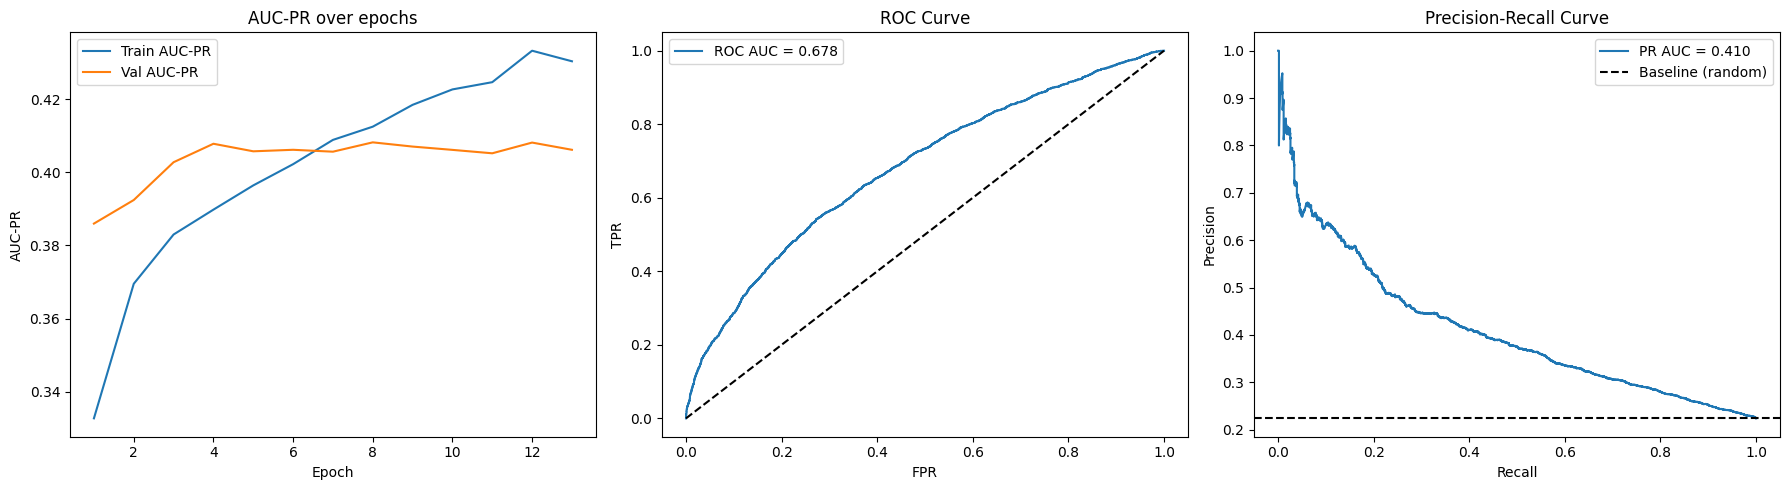

ROC AUC: 0.6785
PR  AUC: 0.4095


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fpr,  tpr,  _ = roc_curve(y_test, y_pred_prob)
prec, rec,  _ = precision_recall_curve(y_test, y_pred_prob)
roc_auc        = auc(fpr, tpr)
pr_auc         = auc(rec, prec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# training curve
ep = range(1, len(history3.history['loss']) + 1)
axes[0].plot(ep, history3.history['auc_pr'],     label='Train AUC-PR')
axes[0].plot(ep, history3.history['val_auc_pr'], label='Val AUC-PR')
axes[0].set_title('AUC-PR over epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC-PR'); axes[0].legend()

# ROC
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

# Precision-Recall
axes[2].plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')
print(f'PR  AUC: {pr_auc:.4f}')

# Notes

## Reading the results
- **AUC-PR** is your most informative metric for this imbalanced task — it measures performance specifically on the positive class.
- **Recall** for the `Readmitted` class tells you how many actual readmissions you caught. This is usually the clinically important direction (false negatives = missed readmissions).
- Watch for the gap between Train AUC-PR and Val AUC-PR in the training curve — a large gap means overfitting.

## Attention layer intuition
The `MultiHeadAttention` layer receives 12 chunks of the embedding (each 64 dims). Each attention head learns to weight relationships between different chunks differently. After pooling, the model has a context-aware summary of the embedding that emphasises the regions most associated with readmission in the training data.

## Rerunning experiments
To try a different sample size or seed, just change `N_SAMPLE` / `RANDOM_SEED` in section 5 and re-run from there — the embedding step (section 4) will use the saved GCS file and skip the 20-minute encode.

## Things to try next
- Increase `num_heads` (4 → 8) or `key_dim` in the attention layer
- Add a second `MultiHeadAttention` block with a residual connection
- Experiment with chunk sizes (e.g. 16 chunks × 48 dims, or 8 chunks × 96 dims)
- Try `N_SAMPLE = 100_000` — the embeddings are already saved, so it costs nothing

## Model with ClinicalBERT embeddings
Full Data Training


In [ ]:
# ── Section 9: Full Dataset Training ──────────────────────────────────────

# --- 9.1  Load full embeddings + build full feature matrix ---
# embeddings_full and df are already in memory from section 4.
# If you're starting a fresh session, re-run sections 1–4 first.

y_full      = df['readmitted_30d'].values
X_struct_full = df.drop(columns=['readmitted_30d', 'discharge_text']).values

print('Full structured features:', X_struct_full.shape)
print('Full embeddings:         ', embeddings_full.shape)
print('Full target:             ', y_full.shape)

Full structured features: (272842, 52)
Full embeddings:          (272842, 768)
Full target:              (272842,)


In [ ]:
# --- 9.2  Train/test split on full dataset ---
from sklearn.model_selection import train_test_split

(
    X_struct_train_f, X_struct_test_f,
    X_emb_train_f,    X_emb_test_f,
    y_train_f,        y_test_f
) = train_test_split(
    X_struct_full, embeddings_full, y_full,
    test_size=0.2, random_state=42, stratify=y_full
)

print('Train size:', X_emb_train_f.shape[0])
print('Test size: ', X_emb_test_f.shape[0])

Train size: 218273
Test size:  54569


In [ ]:
# --- 9.3  Scale structured features ---
from sklearn.preprocessing import StandardScaler

scaler_f = StandardScaler()
X_struct_train_f = scaler_f.fit_transform(X_struct_train_f)
X_struct_test_f  = scaler_f.transform(X_struct_test_f)

In [ ]:
# --- 9.4  Class weights on full training set ---
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes_f = np.array([0, 1])
weights_f = compute_class_weight(class_weight='balanced', classes=classes_f, y=y_train_f)
class_weight_dict_f = dict(zip(classes_f, weights_f))
print('Class weights:', class_weight_dict_f)

Class weights: {np.int64(0): np.float64(0.6444244338814915), np.int64(1): np.float64(2.231009035528844)}


In [ ]:
# --- 9.5  Rebuild model (same architecture, stronger regularisation + label smoothing) ---
# Increased dropout to combat the overfitting seen in the 50k run.
# Label smoothing fixes the jagged PR curve by preventing overconfident predictions.

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

N_STRUCT_F = X_struct_train_f.shape[1]
EMB_DIM    = 768

# text branch
text_input_f = layers.Input(shape=(EMB_DIM,), name='text_embedding')
x_text_f = layers.Reshape((12, 64))(text_input_f)
attn_out  = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text_f, x_text_f)
x_text_f  = layers.LayerNormalization()(attn_out)
x_text_f  = layers.Add()([x_text_f, attn_out])          # residual connection
#x_text_f  = layers.GlobalAveragePooling1D()(x_text_f) # changed to try to get a better signal
x_mean = layers.GlobalAveragePooling1D()(x_text_f)   # captures overall context
x_max  = layers.GlobalMaxPooling1D()(x_text_f)        # captures peak signals
x_text_f = layers.Concatenate()([x_mean, x_max])      # (batch, 128) instead of (batch, 64)
x_text_f  = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x_text_f)
x_text_f  = layers.Dropout(0.4)(x_text_f)               # was 0.3 there was overfitting

# structured branch
struct_input_f = layers.Input(shape=(N_STRUCT_F,), name='structured_features')
x_struct_f = layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(struct_input_f)
x_struct_f = layers.BatchNormalization()(x_struct_f)
x_struct_f = layers.Dropout(0.3)(x_struct_f)
x_struct_f = layers.Dense(64, activation='relu')(x_struct_f)

# merge
merged_f = layers.Concatenate()([x_text_f, x_struct_f])
x_f      = layers.Dense(128, activation='relu')(merged_f)
x_f      = layers.BatchNormalization()(x_f)              # added
x_f      = layers.Dropout(0.35)(x_f)                    # was 0.2 there was overfitting
output_f = layers.Dense(1, activation='sigmoid', name='readmission')(x_f)

model_full = models.Model(
    inputs=[text_input_f, struct_input_f],
    outputs=output_f,
    name='readmission_full'
)

total_steps  = (len(X_emb_train_f) // 128) * 30   # batches × epochs
warmup_steps = total_steps // 10                   # 10% warmup

model_full.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),  # added
    metrics=[
        'accuracy',
        AUC(name='auc'),
        AUC(name='auc_pr', curve='PR'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model_full.summary()

Model: "readmission_full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding      │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 12, 64)    │          0 │ text_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ reshape_5[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 12, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_features │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_4[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ add_4[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │      6,784 │ structured_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_23[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 256)       │     33,024 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 256)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 64)        │      8,256 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 320)       │          0 │ dropout_23[0][0], │
│ (Concatenate)       │                   │            │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     41,088 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_25[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 156,801 (612.50 KB)

 Trainable params: 156,289 (610.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# --- 9.6  Train ---
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks_f = [
    EarlyStopping(
        monitor='val_auc_pr', patience=5, mode='max',
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5, patience=3,
        mode='max', min_lr=1e-6, verbose=1
    )
]

history_full = model_full.fit(
    [X_emb_train_f, X_struct_train_f],
    y_train_f,
    validation_split=0.2,
    epochs=30,
    batch_size=128,                  # larger batch helps stability on bigger data
    class_weight=class_weight_dict_f,
    callbacks=callbacks_f,
    verbose=1
)

Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6141 - auc: 0.6369 - auc_pr: 0.3370 - loss: 0.6949 - precision: 0.3083 - recall: 0.5799 - val_accuracy: 0.6337 - val_auc: 0.6815 - val_auc_pr: 0.4000 - val_loss: 0.6689 - val_precision: 0.3322 - val_recall: 0.6304 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6503 - auc: 0.6795 - auc_pr: 0.3955 - loss: 0.6578 - precision: 0.3410 - recall: 0.6003 - val_accuracy: 0.6881 - val_auc: 0.6905 - val_auc_pr: 0.4125 - val_loss: 0.6235 - val_precision: 0.3680 - val_recall: 0.5487 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6556 - auc: 0.6857 - auc_pr: 0.4030 - loss: 0.6507 - precision: 0.3460 - recall: 0.6024 - val_accuracy: 0.6173 - val_auc: 0.6936 - val_auc_pr: 0.4163 - val_loss: 0.6714 - val_precision: 0.3278 - val_recall: 0.6762 - learning_rate: 0.0010
Epoch 4/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6539 - auc: 

In [ ]:
# --- 9.7  Evaluate ---
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

results_f      = model_full.evaluate([X_emb_test_f, X_struct_test_f], y_test_f, verbose=0)
metric_names_f = model_full.metrics_names

print('\n--- Test Set Results (full dataset) ---')
for name, val in zip(metric_names_f, results_f):
    print(f'  {name:15s}: {val:.4f}')

# threshold tuning
y_pred_prob_f  = model_full.predict([X_emb_test_f, X_struct_test_f]).ravel()
thresholds_f   = np.arange(0.1, 0.9, 0.05)
f1_scores_f    = [f1_score(y_test_f, (y_pred_prob_f > t).astype(int)) for t in thresholds_f]
best_thresh_f  = thresholds_f[np.argmax(f1_scores_f)]
print(f'\nBest threshold: {best_thresh_f:.2f}  (F1 = {max(f1_scores_f):.4f})')

y_pred_f = (y_pred_prob_f > best_thresh_f).astype(int)
print(f'\nClassification Report (threshold = {best_thresh_f:.2f})\n')
print(classification_report(y_test_f, y_pred_f, target_names=['Not Readmitted', 'Readmitted']))


--- Test Set Results (full dataset) ---
  loss           : 0.6433
  compile_metrics: 0.6397
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

Best threshold: 0.50  (F1 = 0.4534)

Classification Report (threshold = 0.50)

                precision    recall  f1-score   support

Not Readmitted       0.87      0.63      0.73     42339
    Readmitted       0.34      0.67      0.45     12230

      accuracy                           0.64     54569
     macro avg       0.61      0.65      0.59     54569
  weighted avg       0.75      0.64      0.67     54569



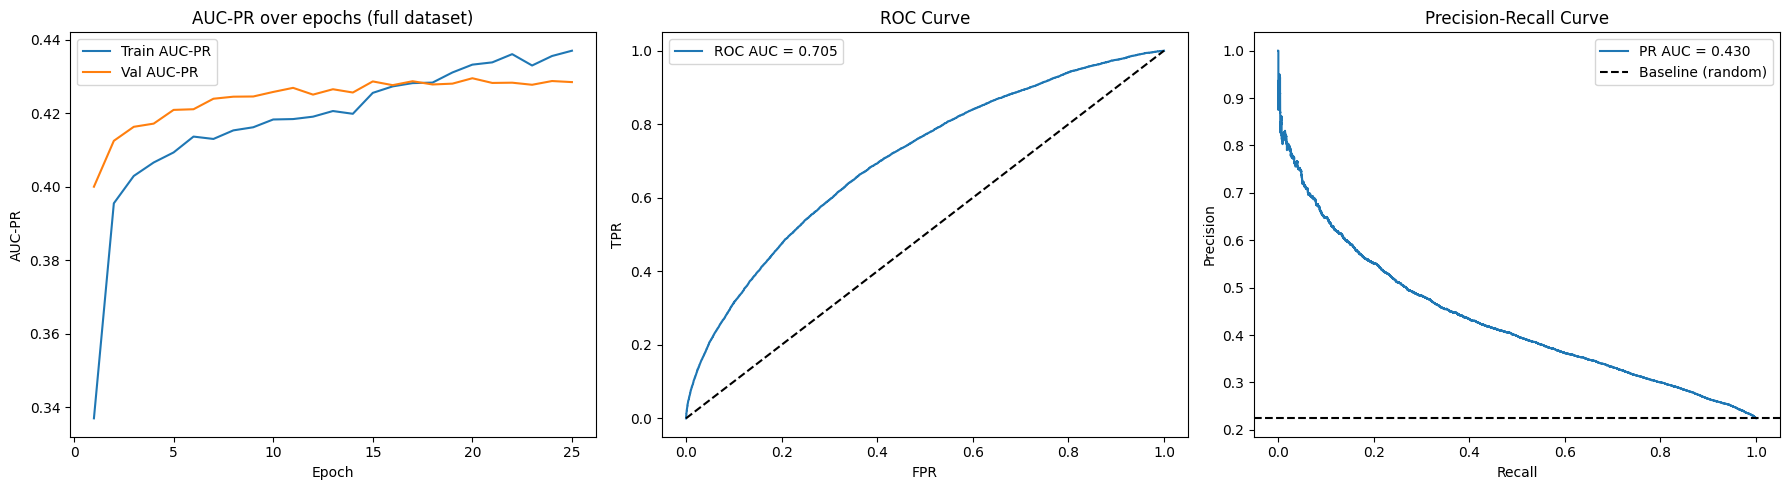

50k model  — ROC AUC: 0.678  |  PR AUC: 0.402
Full model — ROC AUC: 0.705  |  PR AUC: 0.430


In [ ]:
# --- 9.8  Plots ---
fpr_f,  tpr_f,  _ = roc_curve(y_test_f, y_pred_prob_f)
prec_f, rec_f,  _ = precision_recall_curve(y_test_f, y_pred_prob_f)
roc_auc_f          = auc(fpr_f, tpr_f)
pr_auc_f           = auc(rec_f, prec_f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep_f = range(1, len(history_full.history['loss']) + 1)
axes[0].plot(ep_f, history_full.history['auc_pr'],     label='Train AUC-PR')
axes[0].plot(ep_f, history_full.history['val_auc_pr'], label='Val AUC-PR')
axes[0].set_title('AUC-PR over epochs (full dataset)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC-PR'); axes[0].legend()

axes[1].plot(fpr_f, tpr_f, label=f'ROC AUC = {roc_auc_f:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].plot(rec_f, prec_f, label=f'PR AUC = {pr_auc_f:.3f}')
axes[2].axhline(y_test_f.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f'50k model  — ROC AUC: 0.678  |  PR AUC: 0.402')
print(f'Full model — ROC AUC: {roc_auc_f:.3f}  |  PR AUC: {pr_auc_f:.3f}')

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

# wrap model prediction for structured features only
baseline_auc = roc_auc_score(y_test_f, y_pred_prob_f)

importances = []
for i in range(X_struct_test_f.shape[1]):
    X_permuted = X_struct_test_f.copy()
    X_permuted[:, i] = np.random.permutation(X_permuted[:, i])
    preds = model_full.predict([X_emb_test_f, X_permuted], verbose=0).ravel()
    importances.append(baseline_auc - roc_auc_score(y_test_f, preds))

feature_names = df.drop(columns=['readmitted_30d', 'discharge_text']).columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
print(importance_df.sort_values('importance', ascending=False).head(15))

                                       feature  importance
2                             prior_admissions    0.042141
4                                   hemoglobin    0.012703
1                                     los_days    0.010575
45  admission_type_SURGICAL SAME DAY ADMISSION    0.005204
38                             icd10_chapter_Z    0.002773
7                              icd10_chapter_1    0.002500
37                             icd10_chapter_V    0.002279
0                                   anchor_age    0.002195
8                              icd10_chapter_2    0.002070
6                                     gender_M    0.001913
50                           insurance_Private    0.001702
3                                   creatinine    0.001457
18                             icd10_chapter_C    0.001144
46                       admission_type_URGENT    0.001079
34                             icd10_chapter_S    0.001003


In [ ]:
# permute the entire text embedding matrix and see how much AUC drops
X_emb_permuted = X_emb_test_f.copy()
np.random.shuffle(X_emb_permuted)   # shuffle entire rows
preds_no_text  = model_full.predict([X_emb_permuted, X_struct_test_f], verbose=0).ravel()
auc_no_text    = roc_auc_score(y_test_f, preds_no_text)
print(f'AUC with real embeddings:    {baseline_auc:.4f}')
print(f'AUC with shuffled embeddings: {auc_no_text:.4f}')
print(f'Text contribution:            {baseline_auc - auc_no_text:.4f}')

AUC with real embeddings:    0.7047
AUC with shuffled embeddings: 0.6618
Text contribution:            0.0430


## Rich ClinicalBERT Embeddings


In [ ]:
# --- 10.1  Build full feature matrix with rich embeddings ---
# embeddings_rich (N, 2304) already loaded/created above
# df, y_full, X_struct_full are still in memory from section 9

(
    X_struct_train_r, X_struct_test_r,
    X_emb_train_r,    X_emb_test_r,
    y_train_r,        y_test_r
) = train_test_split(
    X_struct_full, embeddings_rich, y_full,
    test_size=0.2, random_state=42, stratify=y_full
)

scaler_r = StandardScaler()
X_struct_train_r = scaler_r.fit_transform(X_struct_train_r)
X_struct_test_r  = scaler_r.transform(X_struct_test_r)

weights_r = compute_class_weight(class_weight='balanced',
                                  classes=np.array([0,1]), y=y_train_r)
class_weight_dict_r = dict(zip([0,1], weights_r))

print('Train embeddings (rich):', X_emb_train_r.shape)   # (N, 2304)
print('Class weights:          ', class_weight_dict_r)

Train embeddings (rich): (218273, 2304)
Class weights:           {0: np.float64(0.6444244338814915), 1: np.float64(2.231009035528844)}


In [ ]:
# NOTE: this was the first attempt at the rich embedding model (no projection).
# Superseded by cell 10.2b below. Kept for reference — do not run before training.

# --- 10.2  Model with rich embedding branch ---
# Only changes vs Section 9:
#   - Input dim: 2304 instead of 768
#   - Reshape: (36, 64) — 3x more chunks, same width
#   - Dual pooling (mean + max) retained from Section 9

EMB_DIM_RICH = 2304
N_STRUCT_R   = X_struct_train_r.shape[1]

# text branch
text_input_r = layers.Input(shape=(EMB_DIM_RICH,), name='text_embedding_rich')
x_text_r     = layers.Reshape((36, 64))(text_input_r)          # 36 chunks × 64 dims
attn_out_r   = layers.MultiHeadAttention(
    num_heads=4, key_dim=64, dropout=0.1)(x_text_r, x_text_r)
x_text_r     = layers.LayerNormalization()(attn_out_r)
x_text_r     = layers.Add()([x_text_r, attn_out_r])            # residual
x_mean_r     = layers.GlobalAveragePooling1D()(x_text_r)
x_max_r      = layers.GlobalMaxPooling1D()(x_text_r)
x_text_r     = layers.Concatenate()([x_mean_r, x_max_r])
x_text_r     = layers.Dense(256, activation='relu',
                             kernel_regularizer=regularizers.l2(1e-4))(x_text_r)
x_text_r     = layers.Dropout(0.4)(x_text_r)

# structured branch (identical to Section 9)
struct_input_r = layers.Input(shape=(N_STRUCT_R,), name='structured_features_rich')
x_struct_r     = layers.Dense(128, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(struct_input_r)
x_struct_r     = layers.BatchNormalization()(x_struct_r)
x_struct_r     = layers.Dropout(0.3)(x_struct_r)
x_struct_r     = layers.Dense(64, activation='relu')(x_struct_r)

# merge
merged_r = layers.Concatenate()([x_text_r, x_struct_r])
x_r      = layers.Dense(128, activation='relu')(merged_r)
x_r      = layers.BatchNormalization()(x_r)
x_r      = layers.Dropout(0.35)(x_r)
output_r = layers.Dense(1, activation='sigmoid', name='readmission')(x_r)

model_rich = models.Model(
    inputs=[text_input_r, struct_input_r],
    outputs=output_r,
    name='readmission_rich'
)

model_rich.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        AUC(name='auc'),
        AUC(name='auc_pr', curve='PR'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model_rich.summary()

Model: "readmission_rich"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding_rich │ (None, 2304)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 36, 64)    │          0 │ text_embedding_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 64)    │     66,368 │ reshape_2[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 64)    │        128 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_feature… │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ add_1[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │      6,784 │ structured_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │     33,024 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 320)       │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     41,088 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ batch_normalizat

 Total params: 156,801 (612.50 KB)

 Trainable params: 156,289 (610.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# --- 10.2b  Model with rich embeddings + projection layer ---

EMB_DIM_RICH = 2304
N_STRUCT_R   = X_struct_train_r.shape[1]

# text branch
text_input_r = layers.Input(shape=(EMB_DIM_RICH,), name='text_embedding_rich')

# project 2304 → 768 before attention so the attention block
# operates at the same capacity as V2, but on richer input
x_text_r = layers.Dense(768, activation='relu')(text_input_r)
x_text_r = layers.Dropout(0.2)(x_text_r)

# attention block — identical to V2
x_text_r = layers.Reshape((12, 64))(x_text_r)
attn_out_r = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text_r, x_text_r)
x_text_r   = layers.LayerNormalization()(attn_out_r)
x_text_r   = layers.Add()([x_text_r, attn_out_r])
x_mean_r   = layers.GlobalAveragePooling1D()(x_text_r)
x_max_r    = layers.GlobalMaxPooling1D()(x_text_r)
x_text_r   = layers.Concatenate()([x_mean_r, x_max_r])
x_text_r   = layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4))(x_text_r)
x_text_r   = layers.Dropout(0.4)(x_text_r)

# structured branch (unchanged)
struct_input_r = layers.Input(shape=(N_STRUCT_R,), name='structured_features_rich')
x_struct_r     = layers.Dense(128, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(struct_input_r)
x_struct_r     = layers.BatchNormalization()(x_struct_r)
x_struct_r     = layers.Dropout(0.3)(x_struct_r)
x_struct_r     = layers.Dense(64, activation='relu')(x_struct_r)

# merge (unchanged)
merged_r = layers.Concatenate()([x_text_r, x_struct_r])
x_r      = layers.Dense(128, activation='relu')(merged_r)
x_r      = layers.BatchNormalization()(x_r)
x_r      = layers.Dropout(0.35)(x_r)
output_r = layers.Dense(1, activation='sigmoid', name='readmission')(x_r)

model_rich = models.Model(
    inputs=[text_input_r, struct_input_r],
    outputs=output_r,
    name='readmission_rich_projected'
)

model_rich.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        AUC(name='auc'),
        AUC(name='auc_pr', curve='PR'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model_rich.summary()

Model: "readmission_rich_projected"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding_rich │ (None, 2304)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 768)       │  1,770,240 │ text_embedding_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 768)       │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 12, 64)    │          0 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ reshape_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_feature… │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ add_2[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │      6,784 │ structured_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     33,024 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 256)       │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 320)       │          0 │ dropout_14[0][0], │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,927,041 (7.35 MB)

 Trainable params: 1,926,529 (7.35 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# --- 10.3  Train ---
callbacks_r = [
    EarlyStopping(
        monitor='val_auc_pr', patience=5, mode='max',
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5, patience=3,
        mode='max', min_lr=1e-6, verbose=1
    )
]

history_rich = model_rich.fit(
    [X_emb_train_r, X_struct_train_r],
    y_train_r,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict_r,
    callbacks=callbacks_r,
    verbose=1
)

Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.6129 - auc: 0.6355 - auc_pr: 0.3388 - loss: 0.6951 - precision: 0.3071 - recall: 0.5784 - val_accuracy: 0.6257 - val_auc: 0.6813 - val_auc_pr: 0.3997 - val_loss: 0.6803 - val_precision: 0.3287 - val_recall: 0.6450 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6493 - auc: 0.6785 - auc_pr: 0.3916 - loss: 0.6594 - precision: 0.3396 - recall: 0.5973 - val_accuracy: 0.5518 - val_auc: 0.6858 - val_auc_pr: 0.4063 - val_loss: 0.7143 - val_precision: 0.3000 - val_recall: 0.7519 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6524 - auc: 0.6813 - auc_pr: 0.3983 - loss: 0.6536 - precision: 0.3424 - recall: 0.5978 - val_accuracy: 0.6472 - val_auc: 0.6839 - val_auc_pr: 0.4068 - val_loss: 0.6438 - val_precision: 0.3402 - val_recall: 0.6138 - learning_rate: 0.0010
Epoch 4/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6521 - auc: 

In [ ]:
# --- 10.4  Evaluate + threshold tuning ---
results_r      = model_rich.evaluate([X_emb_test_r, X_struct_test_r], y_test_r, verbose=0)
metric_names_r = model_rich.metrics_names

print('\n--- Test Set Results (rich embeddings) ---')
for name, val in zip(metric_names_r, results_r):
    print(f'  {name:15s}: {val:.4f}')

y_pred_prob_r = model_rich.predict([X_emb_test_r, X_struct_test_r], verbose=0).ravel()
thresholds_r  = np.arange(0.1, 0.9, 0.05)
f1_scores_r   = [f1_score(y_test_r, (y_pred_prob_r > t).astype(int)) for t in thresholds_r]
best_thresh_r = thresholds_r[np.argmax(f1_scores_r)]

print(f'\nBest threshold: {best_thresh_r:.2f}  (F1 = {max(f1_scores_r):.4f})')
y_pred_r = (y_pred_prob_r > best_thresh_r).astype(int)
print(f'\nClassification Report (threshold = {best_thresh_r:.2f})\n')
print(classification_report(y_test_r, y_pred_r, target_names=['Not Readmitted', 'Readmitted']))


--- Test Set Results (rich embeddings) ---
  loss           : 0.6314
  compile_metrics: 0.6631

Best threshold: 0.50  (F1 = 0.4429)

Classification Report (threshold = 0.50)

                precision    recall  f1-score   support

Not Readmitted       0.85      0.68      0.76     42339
    Readmitted       0.35      0.60      0.44     12230

      accuracy                           0.66     54569
     macro avg       0.60      0.64      0.60     54569
  weighted avg       0.74      0.66      0.69     54569



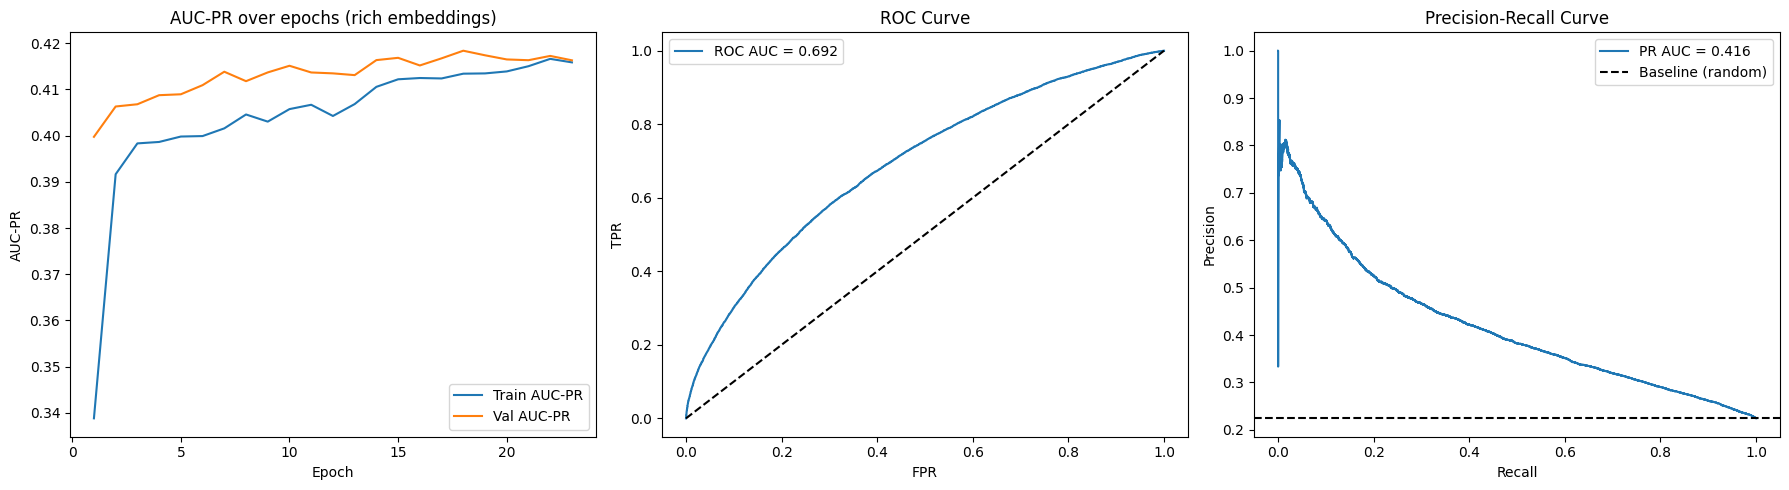


========== Model Progress Summary ==========
  V1 — 50k sample,  mean pool,  focal loss : ROC 0.678  |  PR 0.402
  V2 — full data,   mean pool,  BCE+CW     : ROC 0.704  |  PR 0.429
  V3 — full data,   rich pool,  BCE+CW     : ROC 0.692  |  PR 0.416


In [ ]:
# --- 10.5  Plots + full progress comparison ---
fpr_r,  tpr_r,  _ = roc_curve(y_test_r, y_pred_prob_r)
prec_r, rec_r,  _ = precision_recall_curve(y_test_r, y_pred_prob_r)
roc_auc_r          = auc(fpr_r, tpr_r)
pr_auc_r           = auc(rec_r, prec_r)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep_r = range(1, len(history_rich.history['loss']) + 1)
axes[0].plot(ep_r, history_rich.history['auc_pr'],     label='Train AUC-PR')
axes[0].plot(ep_r, history_rich.history['val_auc_pr'], label='Val AUC-PR')
axes[0].set_title('AUC-PR over epochs (rich embeddings)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC-PR'); axes[0].legend()

axes[1].plot(fpr_r, tpr_r, label=f'ROC AUC = {roc_auc_r:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].plot(rec_r, prec_r, label=f'PR AUC = {pr_auc_r:.3f}')
axes[2].axhline(y_test_r.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()

plt.tight_layout()
plt.show()

# --- full progress summary across all versions ---
print('\n========== Model Progress Summary ==========')
print(f'  V1 — 50k sample,  mean pool,  focal loss : ROC 0.678  |  PR 0.402')
print(f'  V2 — full data,   mean pool,  BCE+CW     : ROC 0.704  |  PR 0.429')
print(f'  V3 — full data,   rich pool,  BCE+CW     : ROC {roc_auc_r:.3f}  |  PR {pr_auc_r:.3f}')
print('============================================')

## Chunked ClinicalBERT Embeddings

In [ ]:
# Initial definition but then included itself in the loop for tracking

def get_chunked_embeddings(texts, batch_size=16, max_length=512, overlap=50):
    stride       = max_length - overlap
    all_note_emb = []
    total        = len(texts)

    for note_idx, text in enumerate(texts):

        # tokenize full note without truncation
        token_ids = tokenizer_cbert.encode(
            text, add_special_tokens=False, truncation=False
        )

        # split into overlapping chunks
        chunks = []
        start  = 0
        while start < len(token_ids):
            end   = start + max_length - 2
            chunk = [tokenizer_cbert.cls_token_id] + token_ids[start:end] + [tokenizer_cbert.sep_token_id]
            chunks.append(chunk)
            if end >= len(token_ids):
                break
            start += stride

        # embed chunks in sub-batches
        chunk_embeddings = []
        for i in range(0, len(chunks), batch_size):
            sub_batch   = chunks[i : i + batch_size]
            max_len_sub = max(len(c) for c in sub_batch)
            input_ids   = torch.zeros(len(sub_batch), max_len_sub, dtype=torch.long)
            attn_mask   = torch.zeros(len(sub_batch), max_len_sub, dtype=torch.long)

            for j, chunk in enumerate(sub_batch):
                input_ids[j, :len(chunk)] = torch.tensor(chunk)
                attn_mask[j, :len(chunk)] = 1

            with torch.no_grad():
                out = model_cbert(
                    input_ids=input_ids.to(device),
                    attention_mask=attn_mask.to(device)
                )

            token_emb  = out.last_hidden_state
            mask_exp   = attn_mask.to(device).unsqueeze(-1).float()
            mean_chunk = (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
            chunk_embeddings.append(mean_chunk.cpu())

        # aggregate across chunks
        chunk_embeddings = torch.cat(chunk_embeddings, dim=0)
        mean_emb = chunk_embeddings.mean(dim=0)
        max_emb  = chunk_embeddings.max(dim=0).values
        all_note_emb.append(torch.cat([mean_emb, max_emb], dim=0).numpy())

        # --- progress reporting ---
        if (note_idx + 1) % 500 == 0 or note_idx == 0:
            pct = (note_idx + 1) / total * 100
            print(f'  [{note_idx+1:>6} / {total}]  {pct:.1f}%  —  last note: {len(chunks)} chunk(s), {len(token_ids)} tokens')

    print(f'\nDone. Embedded {total} notes → shape {np.vstack(all_note_emb).shape}')
    return np.vstack(all_note_emb)

In [ ]:
# --- 11.2  Chunked embeddings with checkpointing ---

CHUNK_EMB_PATH   = BUCKET + 'full_embeddings_chunked.npy'
CHECKPOINT_PATH  = BUCKET + 'checkpoints/chunked_partial.npy'
CHECKPOINT_IDX   = BUCKET + 'checkpoints/chunked_idx.npy'
SAVE_EVERY       = 1000   # save to GCS every N notes

all_texts = df['discharge_text'].tolist()
total     = len(all_texts)

# --- check for existing checkpoint ---
if fs.exists(CHECKPOINT_IDX) and fs.exists(CHECKPOINT_PATH):
    with fs.open(CHECKPOINT_IDX, 'rb') as f:
        start_idx = int(np.load(f))
    with fs.open(CHECKPOINT_PATH, 'rb') as f:
        completed = list(np.load(f))
    print(f'Resuming from note {start_idx} / {total}  ({start_idx/total*100:.1f}% already done)')
else:
    start_idx = 0
    completed = []
    print(f'Starting fresh — {total} notes to embed')

# --- main loop ---
for note_idx, text in enumerate(all_texts[start_idx:], start=start_idx):

    token_ids = tokenizer_cbert.encode(
        text, add_special_tokens=False, truncation=False
    )

    stride = 512 - 50
    chunks = []
    start  = 0
    while start < len(token_ids):
        end   = start + 510   # 512 - 2 for [CLS] and [SEP]
        chunk = [tokenizer_cbert.cls_token_id] + token_ids[start:end] + [tokenizer_cbert.sep_token_id]
        chunks.append(chunk)
        if end >= len(token_ids):
            break
        start += stride

    chunk_embeddings = []
    for i in range(0, len(chunks), 16):
        sub_batch   = chunks[i : i + 16]
        max_len_sub = max(len(c) for c in sub_batch)
        input_ids   = torch.zeros(len(sub_batch), max_len_sub, dtype=torch.long)
        attn_mask   = torch.zeros(len(sub_batch), max_len_sub, dtype=torch.long)

        for j, chunk in enumerate(sub_batch):
            input_ids[j, :len(chunk)] = torch.tensor(chunk)
            attn_mask[j, :len(chunk)] = 1

        with torch.no_grad():
            out = model_cbert(
                input_ids=input_ids.to(device),
                attention_mask=attn_mask.to(device)
            )

        token_emb  = out.last_hidden_state
        mask_exp   = attn_mask.to(device).unsqueeze(-1).float()
        mean_chunk = (token_emb * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        chunk_embeddings.append(mean_chunk.cpu())

    chunk_embeddings = torch.cat(chunk_embeddings, dim=0)
    mean_emb = chunk_embeddings.mean(dim=0)
    max_emb  = chunk_embeddings.max(dim=0).values
    completed.append(torch.cat([mean_emb, max_emb], dim=0).numpy())

    # --- progress print every 500 notes ---
    if (note_idx + 1) % 500 == 0 or note_idx == start_idx:
        pct = (note_idx + 1) / total * 100
        print(f'  [{note_idx+1:>6} / {total}]  {pct:.1f}%  —  {len(chunks)} chunk(s), {len(token_ids)} tokens')

    # --- checkpoint save every SAVE_EVERY notes ---
    if (note_idx + 1) % SAVE_EVERY == 0:
        print(f'  Saving checkpoint at note {note_idx+1}...')
        with fs.open(CHECKPOINT_PATH, 'wb') as f:
            np.save(f, np.vstack(completed))
        with fs.open(CHECKPOINT_IDX, 'wb') as f:
            np.save(f, np.array([note_idx + 1]))
        print(f'  Checkpoint saved.')

# --- final save ---
embeddings_chunked = np.vstack(completed)
with fs.open(CHUNK_EMB_PATH, 'wb') as f:
    np.save(f, embeddings_chunked)
print(f'\nFinal embeddings saved to {CHUNK_EMB_PATH}')
print(f'Shape: {embeddings_chunked.shape}')

# clean up checkpoints now that we have the full file
if fs.exists(CHECKPOINT_PATH): fs.rm(CHECKPOINT_PATH)
if fs.exists(CHECKPOINT_IDX):  fs.rm(CHECKPOINT_IDX)
print('Checkpoints cleaned up.')

Starting fresh — 272842 notes to embed
  [     1 / 272842]  0.0%  —  4 chunk(s), 1523 tokens
  [   500 / 272842]  0.2%  —  3 chunk(s), 1277 tokens
  [  1000 / 272842]  0.4%  —  9 chunk(s), 4065 tokens
  Saving checkpoint at note 1000...
  Checkpoint saved.
  [  1500 / 272842]  0.5%  —  5 chunk(s), 2313 tokens
  [  2000 / 272842]  0.7%  —  7 chunk(s), 3082 tokens
  Saving checkpoint at note 2000...
  Checkpoint saved.
  [  2500 / 272842]  0.9%  —  2 chunk(s), 628 tokens
  [  3000 / 272842]  1.1%  —  5 chunk(s), 1966 tokens
  Saving checkpoint at note 3000...
  Checkpoint saved.
  [  3500 / 272842]  1.3%  —  9 chunk(s), 4056 tokens
  [  4000 / 272842]  1.5%  —  7 chunk(s), 2884 tokens
  Saving checkpoint at note 4000...
  Checkpoint saved.
  [  4500 / 272842]  1.6%  —  5 chunk(s), 2340 tokens
  [  5000 / 272842]  1.8%  —  7 chunk(s), 3081 tokens
  Saving checkpoint at note 5000...
  Checkpoint saved.
  [  5500 / 272842]  2.0%  —  9 chunk(s), 4071 tokens
  [  6000 / 272842]  2.2%  —  5 ch

In [ ]:
# --- 11.3  Split + scale ---

(
    X_struct_train_c, X_struct_test_c,
    X_emb_train_c,    X_emb_test_c,
    y_train_c,        y_test_c
) = train_test_split(
    X_struct_full, embeddings_chunked, y_full,
    test_size=0.2, random_state=42, stratify=y_full
)

scaler_c = StandardScaler()
X_struct_train_c = scaler_c.fit_transform(X_struct_train_c)
X_struct_test_c  = scaler_c.transform(X_struct_test_c)

weights_c = compute_class_weight(class_weight='balanced',
                                  classes=np.array([0,1]), y=y_train_c)
class_weight_dict_c = dict(zip([0,1], weights_c))

print('Chunked embeddings train:', X_emb_train_c.shape)   # (N, 1536)
print('Class weights:           ', class_weight_dict_c)

Chunked embeddings train: (218273, 1536)
Class weights:            {0: np.float64(0.6444244338814915), 1: np.float64(2.231009035528844)}


In [ ]:
# --- 11.4  Model ---
# 1536-dim input projected to 768 before attention — same logic as the
# projection fix in 10.2b, which kept attention capacity consistent with V2

EMB_DIM_CHUNK = 1536
N_STRUCT_C    = X_struct_train_c.shape[1]

# text branch
text_input_c = layers.Input(shape=(EMB_DIM_CHUNK,), name='text_embedding_chunked')
x_text_c     = layers.Dense(768, activation='relu')(text_input_c)  # project down
x_text_c     = layers.Dropout(0.2)(x_text_c)
x_text_c     = layers.Reshape((12, 64))(x_text_c)
attn_out_c   = layers.MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x_text_c, x_text_c)
x_text_c     = layers.LayerNormalization()(attn_out_c)
x_text_c     = layers.Add()([x_text_c, attn_out_c])
x_mean_c     = layers.GlobalAveragePooling1D()(x_text_c)
x_max_c      = layers.GlobalMaxPooling1D()(x_text_c)
x_text_c     = layers.Concatenate()([x_mean_c, x_max_c])
x_text_c     = layers.Dense(256, activation='relu',
                             kernel_regularizer=regularizers.l2(1e-4))(x_text_c)
x_text_c     = layers.Dropout(0.4)(x_text_c)

# structured branch (unchanged)
struct_input_c = layers.Input(shape=(N_STRUCT_C,), name='structured_features_chunked')
x_struct_c     = layers.Dense(128, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(struct_input_c)
x_struct_c     = layers.BatchNormalization()(x_struct_c)
x_struct_c     = layers.Dropout(0.3)(x_struct_c)
x_struct_c     = layers.Dense(64, activation='relu')(x_struct_c)

# merge
merged_c = layers.Concatenate()([x_text_c, x_struct_c])
x_c      = layers.Dense(128, activation='relu')(merged_c)
x_c      = layers.BatchNormalization()(x_c)
x_c      = layers.Dropout(0.35)(x_c)
output_c = layers.Dense(1, activation='sigmoid', name='readmission')(x_c)

model_chunked = models.Model(
    inputs=[text_input_c, struct_input_c],
    outputs=output_c,
    name='readmission_chunked'
)

model_chunked.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        'accuracy',
        AUC(name='auc'),
        AUC(name='auc_pr', curve='PR'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model_chunked.summary()

Model: "readmission_chunked"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_embedding_chu… │ (None, 1536)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 768)       │  1,180,416 │ text_embedding_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 768)       │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 12, 64)    │          0 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │     66,368 │ reshape_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 12, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_feature… │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ add_3[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ add_3[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │      6,784 │ structured_featu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_19[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │     33,024 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 256)       │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      8,256 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 320)       │          0 │ dropout_19[0][0], │
│ (Concatenate)       │                   │            │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,337,217 (5.10 MB)

 Trainable params: 1,336,705 (5.10 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# --- 11.5  Train ---

callbacks_c = [
    EarlyStopping(
        monitor='val_auc_pr', patience=5, mode='max',
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr', factor=0.5, patience=3,
        mode='max', min_lr=1e-6, verbose=1
    )
]

history_chunked = model_chunked.fit(
    [X_emb_train_c, X_struct_train_c],
    y_train_c,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict_c,
    callbacks=callbacks_c,
    verbose=1
)

Epoch 1/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.6190 - auc: 0.6400 - auc_pr: 0.3435 - loss: 0.6935 - precision: 0.3111 - recall: 0.5759 - val_accuracy: 0.6357 - val_auc: 0.6931 - val_auc_pr: 0.4127 - val_loss: 0.6671 - val_precision: 0.3365 - val_recall: 0.6460 - learning_rate: 0.0010
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6530 - auc: 0.6846 - auc_pr: 0.4006 - loss: 0.6554 - precision: 0.3433 - recall: 0.5998 - val_accuracy: 0.6968 - val_auc: 0.6976 - val_auc_pr: 0.4216 - val_loss: 0.6219 - val_precision: 0.3781 - val_recall: 0.5502 - learning_rate: 0.0010
Epoch 3/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6557 - auc: 0.6908 - auc_pr: 0.4067 - loss: 0.6478 - precision: 0.3475 - recall: 0.6106 - val_accuracy: 0.7092 - val_auc: 0.6997 - val_auc_pr: 0.4237 - val_loss: 0.6082 - val_precision: 0.3892 - val_recall: 0.5264 - learning_rate: 0.0010
Epoch 4/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6582 - auc: 

In [ ]:
# --- 11.6  Evaluate + threshold tuning ---

results_c      = model_chunked.evaluate([X_emb_test_c, X_struct_test_c], y_test_c, verbose=0)
metric_names_c = model_chunked.metrics_names

print('\n--- Test Set Results (chunked embeddings) ---')
for name, val in zip(metric_names_c, results_c):
    print(f'  {name:15s}: {val:.4f}')

y_pred_prob_c = model_chunked.predict([X_emb_test_c, X_struct_test_c], verbose=0).ravel()
thresholds_c  = np.arange(0.1, 0.9, 0.05)
f1_scores_c   = [f1_score(y_test_c, (y_pred_prob_c > t).astype(int)) for t in thresholds_c]
best_thresh_c = thresholds_c[np.argmax(f1_scores_c)]

print(f'\nBest threshold: {best_thresh_c:.2f}  (F1 = {max(f1_scores_c):.4f})')
y_pred_c = (y_pred_prob_c > best_thresh_c).astype(int)
print(f'\nClassification Report (threshold = {best_thresh_c:.2f})\n')
print(classification_report(y_test_c, y_pred_c, target_names=['Not Readmitted', 'Readmitted']))


--- Test Set Results (chunked embeddings) ---
  loss           : 0.6094
  compile_metrics: 0.6900

Best threshold: 0.50  (F1 = 0.4585)

Classification Report (threshold = 0.50)

                precision    recall  f1-score   support

Not Readmitted       0.86      0.72      0.78     42339
    Readmitted       0.38      0.59      0.46     12230

      accuracy                           0.69     54569
     macro avg       0.62      0.65      0.62     54569
  weighted avg       0.75      0.69      0.71     54569



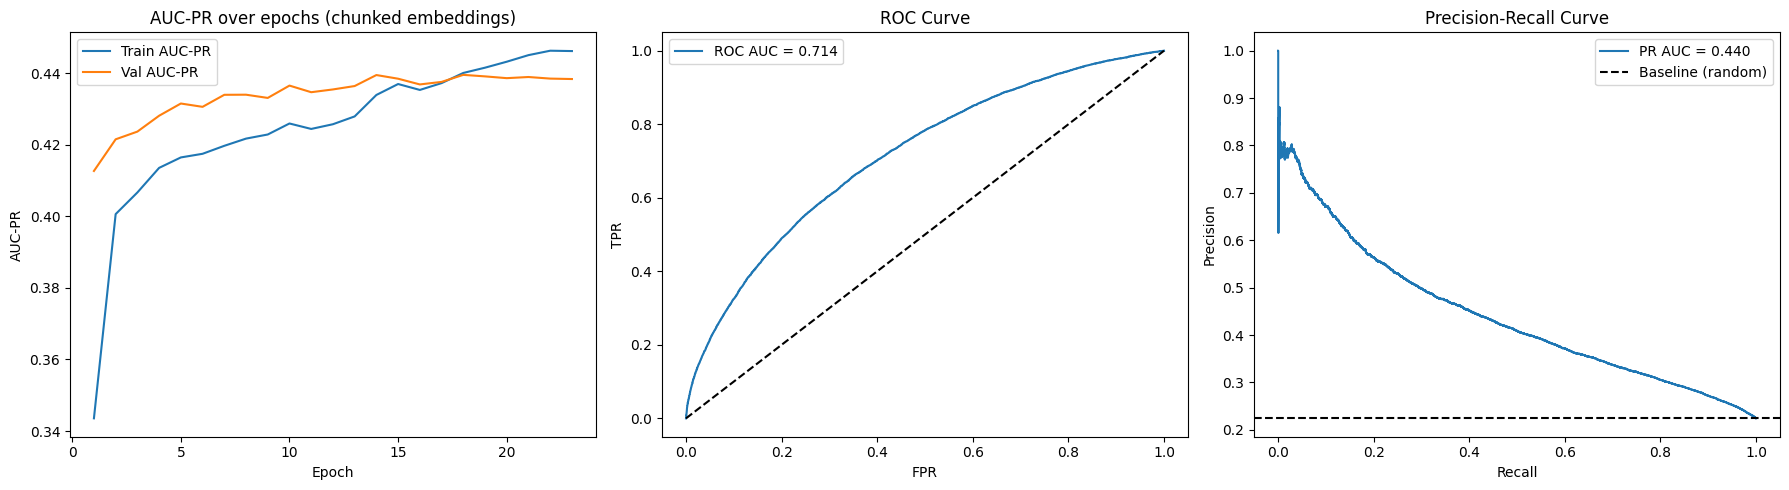


========== Model Progress Summary ==========
  V1 — 50k sample,  mean pool,       focal loss : ROC 0.678  |  PR 0.402
  V2 — full data,   mean pool,       BCE+CW     : ROC 0.704  |  PR 0.429
  V3 — full data,   rich pool,       BCE+CW     : ROC 0.699  |  PR 0.423
  V4 — full data,   chunked pool,    BCE+CW     : ROC 0.714  |  PR 0.440


In [ ]:
# --- 11.7  Plots + updated progress summary ---

fpr_c,  tpr_c,  _ = roc_curve(y_test_c, y_pred_prob_c)
prec_c, rec_c,  _ = precision_recall_curve(y_test_c, y_pred_prob_c)
roc_auc_c          = auc(fpr_c, tpr_c)
pr_auc_c           = auc(rec_c, prec_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ep_c = range(1, len(history_chunked.history['loss']) + 1)
axes[0].plot(ep_c, history_chunked.history['auc_pr'],     label='Train AUC-PR')
axes[0].plot(ep_c, history_chunked.history['val_auc_pr'], label='Val AUC-PR')
axes[0].set_title('AUC-PR over epochs (chunked embeddings)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC-PR'); axes[0].legend()

axes[1].plot(fpr_c, tpr_c, label=f'ROC AUC = {roc_auc_c:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].plot(rec_c, prec_c, label=f'PR AUC = {pr_auc_c:.3f}')
axes[2].axhline(y_test_c.mean(), color='k', linestyle='--', label='Baseline (random)')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()

plt.tight_layout()
plt.show()

# --- full progress summary ---
print('\n========== Model Progress Summary ==========')
print(f'  V1 — 50k sample,  mean pool,       focal loss : ROC 0.678  |  PR 0.402')
print(f'  V2 — full data,   mean pool,       BCE+CW     : ROC 0.704  |  PR 0.429')
print(f'  V3 — full data,   rich pool,       BCE+CW     : ROC 0.699  |  PR 0.423')
print(f'  V4 — full data,   chunked pool,    BCE+CW     : ROC {roc_auc_c:.3f}  |  PR {pr_auc_c:.3f}')
print('============================================')